# Dropout
은닉층의 뉴런이 많아질수록 모델은 복잡한 패턴을 더 잘 표현할 수 있다.
하지만 그만큼 학습 데이터의 우연한 잡음까지 외워버릴 가능성도 있다.

Dropout은 학습 중 일부 뉴런을 확률적으로 꺼서, 
특정 뉴런 몇 개에만 지나치게 의존하지 않도록 만드는 대표적인 regularization 기법이다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

## 1. Dropout 동작 방법
 - 학습시에 일부 뉴런이 무작위로 비활성화 된다.
 - 평가 시에는 모든 뉴런을 사용한다.
 - 따라서 `model.train()`, `model.eval()`의 전환이 매우 중요하다.

In [3]:
x = torch.tensor([1., 2., 3., 4., 5.])

# Dropout 객체 생성 (각 원소를 약 40% 확률로 끈다)
drop = nn.Dropout(p=0.4)

# 학습 모드 : 일부 값이 랜덤하게 0이 된다.
# 살아 남은 값은 1 / (1 - p) 만큼 키워서 출력한다. (dropout의 스케일 보정)
drop.train()
print('train mode 1:', drop(x))
print('train mode 2:', drop(x))
print('train mode 3:', drop(x))

# 평가 모드 : dropout을 적용하지 않고 입력을 그대로 사용한다.
drop.eval()
print('eval mode 1:', drop(x))
print('eval mode 2:', drop(x))
print('eval mode 3:', drop(x))

train mode 1: tensor([1.6667, 3.3333, 5.0000, 6.6667, 8.3333])
train mode 2: tensor([1.6667, 0.0000, 0.0000, 6.6667, 8.3333])
train mode 3: tensor([1.6667, 3.3333, 0.0000, 0.0000, 8.3333])
eval mode 1: tensor([1., 2., 3., 4., 5.])
eval mode 2: tensor([1., 2., 3., 4., 5.])
eval mode 3: tensor([1., 2., 3., 4., 5.])


## 2. dropout rate `p`의 의미

보통 너무 작으면 regularization 효과가 약하고, 너무 크면 학습에 필요한 정보까지 과하게 잃을 수 있다.

실무적으로 완전한 규칙이 있는 것은 아니지만, MLP에서는 `0.2 ~ 0.5` 부근을 자주 실험해본다.

In [4]:
# 같은 입력에 대해 p 값이 다를 때의 예시
x = torch.ones(10)

for p in [0.1, 0.3, 0.5, 0.7]:
    drop = nn.Dropout(p=p)
    drop.train()
    print(f'{p=}, {drop(x)}')

p=0.1, tensor([1.1111, 1.1111, 1.1111, 1.1111, 1.1111, 1.1111, 1.1111, 1.1111, 1.1111,
        1.1111])
p=0.3, tensor([1.4286, 0.0000, 1.4286, 1.4286, 1.4286, 1.4286, 1.4286, 1.4286, 1.4286,
        1.4286])
p=0.5, tensor([0., 0., 2., 2., 2., 0., 2., 2., 2., 0.])
p=0.7, tensor([0.0000, 0.0000, 3.3333, 0.0000, 0.0000, 0.0000, 0.0000, 3.3333, 0.0000,
        0.0000])


## 3. 실습
MLP에서는 보통 다음과 같은 흐름을 사용한다.
`Linear -> Activation(ReLU) -> Dropout`

 - 선형 변환을 하고
 - 활성화 함수를 통과 시킨 뒤
 - 그 결과 일부를 학습 중에만 무작위로 끄는 식이다.

In [9]:
class MLPWithoutDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

class MLPWithDropout(nn.Module):
    def __init__(self, p=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

In [17]:
# 이진분류용 toy 데이터 생성
X, y = make_moons(n_samples=800, noise=0.25, random_state=42)

# 전체 데이터를 학습용 / 검증용으로 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 입력 값 X는 실수 연산이 필요하므로 타입 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

# 정답 y는 손실함수에서 처리 될 shape로 2차원으로 맞춰준다
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

In [18]:
# 모델 학습 함수
def train_binary_model(model, X_train, y_train, X_val, y_val, epochs=300, lr=0.01):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
        
    for epoch in range(epochs):
        # 학습 모드 : dropout이 켜진다.
        model.train()
        optimizer.zero_grad()
        train_logits = model(X_train)
        train_loss = criterion(train_logits, y_train)
        train_loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            train_pred = (torch.sigmoid(train_logits) >= 0.5).float()
            train_acc = (train_pred == y_train).float().mean().item()
            
        # 평가 모드: dropout이 꺼진다.
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val)
            val_pred = (torch.sigmoid(val_logits) >= 0.5).float()
            val_acc = (val_pred == y_val).float().mean().item()
    
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_accs.append(train_acc)
        val_accs.append(val_acc)
    
    return train_losses, val_losses, train_accs, val_accs

In [19]:
torch.manual_seed(42)
model_no_dropout = MLPWithoutDropout()

torch.manual_seed(42)
model_dropout = MLPWithDropout()

hist_no = train_binary_model(model_no_dropout, X_train, y_train, X_val, y_val)
hist_do = train_binary_model(model_dropout, X_train, y_train, X_val, y_val)

no_train_loss, no_val_loss, no_train_acc, no_val_acc = hist_no
do_train_loss, do_val_loss, do_train_acc, do_val_acc = hist_do

print('without dropout - final train acc : ', round(no_train_acc[-1], 4))
print('without dropout - final val acc : ', round(no_val_acc[-1], 4))

print('with dropout - final train acc : ', round(do_train_acc[-1], 4))
print('with dropout - final train acc : ', round(do_val_acc[-1], 4))

without dropout - final train acc :  0.9533
without dropout - final val acc :  0.94
with dropout - final train acc :  0.9417
with dropout - final train acc :  0.95


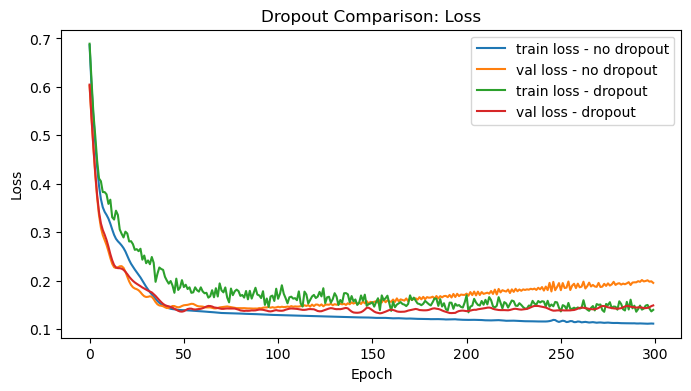

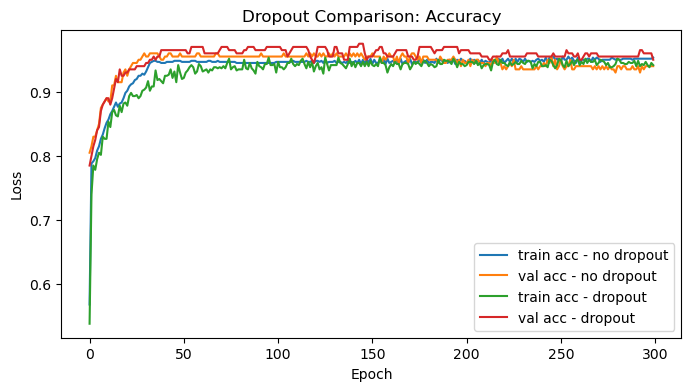

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(no_train_loss, label='train loss - no dropout')
plt.plot(no_val_loss, label='val loss - no dropout')
plt.plot(do_train_loss, label='train loss - dropout')
plt.plot(do_val_loss, label='val loss - dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Dropout Comparison: Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(no_train_acc, label='train acc - no dropout')
plt.plot(no_val_acc, label='val acc - no dropout')
plt.plot(do_train_acc, label='train acc - dropout')
plt.plot(do_val_acc, label='val acc - dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Dropout Comparison: Accuracy')
plt.legend()
plt.show()

1. Dropout이 없는 모델은 훈련 성능이 더 빨리 좋아질 수 있다.
2. 하지만 검증 성능이 비슷하거나 오히려 불안정해질 수 있다.
3. Dropout이 있는 모델은 훈련이 약간 더 어렵지만, 일반화 측면에서 이점이 생길 수 있다.